# Ticket Triage Agent: Cleaning, Sampling, Claude Classification & Metrics

This notebook covers the full pipeline for the multilingual support ticket triage project:

1. Load & clean the raw dataset
2. Stratified sampling (by language + queue) for a manageable Claude API test set
3. Call Claude to classify `queue` / `priority` and draft a reply for each ticket
4. Compute accuracy metrics and a breakdown by language / queue

**Before running:** put `dataset-tickets-multi-lang3-4k.csv` in the same folder as this notebook, and set your API key as an environment variable (or in the cell below) before running Section 3.


## 0. Setup

In [1]:
import os
import json
import time
import csv
from pathlib import Path

import pandas as pd
import numpy as np

INPUT_FILE = "dataset-tickets-multi-lang3-4k.csv"
CLEANED_FILE = "cleaned_tickets_full.csv"
SAMPLE_FILE = "sampled_tickets_test.csv"
RESULTS_FILE = "results_partial.csv"

SAMPLE_SIZE = 250
RANDOM_SEED = 42


## 1. Load & clean the data

- Drop rows with no ticket body
- Fill missing subjects using the first few words of the body
- Filter out noisy/duplicate `business_type` labels
- Consolidate `tag_1..tag_9` into a single `tags` list column


In [2]:
VALID_BUSINESS_TYPES = {
    "IT Services",
    "Tech Online Store",
    "IT Consulting Firm",
    "Software Development Company",
    "Online Store",
}

df_raw = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df_raw)} rows, {len(df_raw.columns)} columns")
df_raw.head(3)


Loaded 4000 rows, 17 columns


,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
0,Problema crítico del servidor requiere atenció...,Es necesaria una investigación inmediata sobre...,Estamos investigando urgentemente el problema ...,Incident,Technical Support,high,es,IT Services,Urgent Issue,Service Disruption,Incident Report,Service Recovery,System Maintenance,NaN,NaN,NaN,NaN
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice,\n\nich hoffe, die...","Sehr geehrter <name>,\n\nvielen Dank, dass Sie...",Request,Customer Service,low,de,Tech Online Store,Sales Inquiry,Product Support,Customer Service,Order Issue,Returns and Exchanges,NaN,NaN,NaN,NaN
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es...","Prezado <name>,\n\nObrigado por entrar em cont...",Incident,Technical Support,high,pt,IT Services,Technical Support,Software Bug,Problem Resolution,Urgent Issue,IT Support,NaN,NaN,NaN,NaN


In [3]:
df = df_raw.copy()

# Drop rows with empty body
before = len(df)
df = df.dropna(subset=["body"])
print(f"Dropped {before - len(df)} rows with empty body")

# Fill missing subject from the first 8 words of the body
def fallback_subject(row):
    if pd.isna(row["subject"]) or str(row["subject"]).strip() == "":
        words = str(row["body"]).split()
        return " ".join(words[:8]) + ("..." if len(words) > 8 else "")
    return row["subject"]

df["subject"] = df.apply(fallback_subject, axis=1)

# Filter out junk business_type labels
before = len(df)
df = df[df["business_type"].isin(VALID_BUSINESS_TYPES)]
print(f"Dropped {before - len(df)} rows with junk business_type labels")

# Consolidate tag_1..tag_9 into a single list column
tag_cols = [c for c in df.columns if c.startswith("tag_")]
df["tags"] = df[tag_cols].apply(lambda row: [t for t in row if pd.notna(t)], axis=1)
df = df.drop(columns=tag_cols)

# Normalize whitespace
for col in ["subject", "body", "answer"]:
    df[col] = df[col].astype(str).str.strip()

df = df.reset_index(drop=True)
print(f"Final cleaned dataset: {len(df)} rows")

df.to_csv(CLEANED_FILE, index=False)
df.head(3)


Dropped 1 rows with empty body
Dropped 16 rows with junk business_type labels
Final cleaned dataset: 3983 rows


,subject,body,answer,type,queue,priority,language,business_type,tags
0,Problema crítico del servidor requiere atenció...,Es necesaria una investigación inmediata sobre...,Estamos investigando urgentemente el problema ...,Incident,Technical Support,high,es,IT Services,"[Urgent Issue, Service Disruption, Incident Re..."
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice,\n\nich hoffe, die...","Sehr geehrter <name>,\n\nvielen Dank, dass Sie...",Request,Customer Service,low,de,Tech Online Store,"[Sales Inquiry, Product Support, Customer Serv..."
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es...","Prezado <name>,\n\nObrigado por entrar em cont...",Incident,Technical Support,high,pt,IT Services,"[Technical Support, Software Bug, Problem Reso..."


In [4]:
# Quick distribution check
print("Language distribution:")
print(df["language"].value_counts())
print()
print("Queue distribution:")
print(df["queue"].value_counts())
print()
print("Priority distribution:")
print(df["priority"].value_counts())


Language distribution:
language
en    1386
de     841
es     810
fr     475
pt     471
Name: count, dtype: int64

Queue distribution:
queue
Technical Support                  1306
Product Support                     687
Customer Service                    624
IT Support                          445
Billing and Payments                338
Returns and Exchanges               197
Service Outages and Maintenance     141
Sales and Pre-Sales                 137
General Inquiry                      55
Human Resources                      53
Name: count, dtype: int64

Priority distribution:
priority
high      1640
medium    1598
low        745
Name: count, dtype: int64


## 2. Stratified sampling

We stratify by `language + queue` so the test sample preserves the real distribution of both. This matters because both language and queue are imbalanced in the source data — a random sample without stratification could easily under-represent smaller queues like "Human Resources" or "General Inquiry".


In [5]:
def stratified_sample(df, n, seed):
    df = df.copy()
    df["strata"] = df["language"] + "_" + df["queue"]

    frac = n / len(df)
    sample_parts = []

    for stratum, group in df.groupby("strata"):
        take = max(1, round(len(group) * frac))
        take = min(take, len(group))
        sample_parts.append(group.sample(n=take, random_state=seed))

    sample = pd.concat(sample_parts)

    if len(sample) > n:
        sample = sample.sample(n=n, random_state=seed)
    elif len(sample) < n:
        remaining = df.drop(sample.index)
        extra = remaining.sample(n=min(n - len(sample), len(remaining)), random_state=seed)
        sample = pd.concat([sample, extra])

    return sample.drop(columns=["strata"]).reset_index(drop=True)

sample = stratified_sample(df, SAMPLE_SIZE, RANDOM_SEED)
sample.to_csv(SAMPLE_FILE, index=False)
print(f"Stratified sample: {len(sample)} rows")
sample.head(3)


Stratified sample: 250 rows


,subject,body,answer,type,queue,priority,language,business_type,tags
0,Asistencia requerida para la configuración del...,Estimado soporte al cliente de la empresa de c...,"Estimado <name>,\n\nGracias por contactarnos r...",Incident,Product Support,medium,es,IT Consulting Firm,"[Technical Support, IT Support, Software Bug, ..."
1,Konnektivitätsproblem: Kann keine Slack-Nachri...,"Sehr geehrter Kundenservice,\n\nich wende mich...","Sehr geehrter <name>,\n\nvielen Dank, dass Sie...",Incident,Customer Service,low,de,IT Services,"[Technical Support, Service Disruption, Custom..."
2,"Dear Customer Support, I am writing to request...","Dear Customer Support,\n\nI am writing to requ...","Dear <name>,\n\nThank you for reaching out abo...",Request,Technical Support,high,en,IT Services,"[Technical Guidance, IT Support, Problem Resol..."


In [6]:
# Verify the sample distribution matches the full dataset
print("--- Language: full vs sample ---")
full_lang = df["language"].value_counts(normalize=True).round(3)
samp_lang = sample["language"].value_counts(normalize=True).round(3)
display(pd.concat([full_lang, samp_lang], axis=1, keys=["full", "sample"]))

print("--- Queue: full vs sample ---")
full_q = df["queue"].value_counts(normalize=True).round(3)
samp_q = sample["queue"].value_counts(normalize=True).round(3)
display(pd.concat([full_q, samp_q], axis=1, keys=["full", "sample"]))


--- Language: full vs sample ---


,full,sample
language,,
en,0.348,0.344
de,0.211,0.208
es,0.203,0.204
fr,0.119,0.120
pt,0.118,0.124


--- Queue: full vs sample ---


,full,sample
queue,,
Technical Support,0.328,0.320
Product Support,0.172,0.176
Customer Service,0.157,0.156
IT Support,0.112,0.108
Billing and Payments,0.085,0.084
Returns and Exchanges,0.049,0.044
Service Outages and Maintenance,0.035,0.036
Sales and Pre-Sales,0.034,0.036
General Inquiry,0.014,0.020


## 3. Claude classification + reply drafting

For each ticket, Claude returns:
- `queue`: predicted routing department (from a fixed label set, to keep accuracy comparisons meaningful)
- `priority`: predicted urgency (low / medium / high)
- `reply_draft`: a short reply in the ticket's own language

**Setup:** `pip install anthropic` in your Jupyter environment, then either export `ANTHROPIC_API_KEY` before launching Jupyter, or set it directly in the cell below.

This section writes to `results_partial.csv` incrementally, so if you stop and rerun the loop cell, already-processed rows are skipped (no wasted API calls).


In [8]:
# !pip install anthropic   # uncomment and run once if not already installed

import anthropic

# Option A: read from environment variable (recommended)
# api_key = os.environ.get("ANTHROPIC_API_KEY")

# Option B: uncomment and paste your key directly (fine for local notebook use,
# just don't commit this to a public repo)
api_key = "..."

if not api_key:
    raise RuntimeError("Set ANTHROPIC_API_KEY as an environment variable, or paste it in Option B above.")

client = anthropic.Anthropic(api_key=api_key)
print("Claude client ready")


Claude client ready


In [35]:
MODEL = "claude-sonnet-4-6"

QUEUE_LABELS = [
    "Technical Support",
    "Product Support",
    "Customer Service",
    "IT Support",
    "Billing and Payments",
    "Returns and Exchanges",
    "Service Outages and Maintenance",
    "Sales and Pre-Sales",
    "General Inquiry",
    "Human Resources",
]

QUEUE_DEFINITIONS = """
- Technical Support: bugs, errors, crashes, or malfunctions in a SPECIFIC software
  application or feature the customer is using (e.g. "app crashes when I upload a file").
- IT Support: infrastructure-level issues -- network connectivity, server access,
  account login/authentication, hardware, VPN, or system administration problems.
  NOT about a specific software feature breaking (that's Technical Support).
- Product Support: questions about HOW TO USE or configure a product/feature
  (how-to, setup, usage guidance) -- not a bug report, not an infrastructure issue.
- Customer Service: general complaints, dissatisfaction, or requests that do NOT
  involve a technical problem, billing issue, or specific product question.
  Use this as the default for vague/general customer complaints.
- Billing and Payments: invoices, charges, refunds related to payment (not product returns),
  subscription costs, payment method issues.
- Returns and Exchanges: physical product returns, exchanges, or replacement requests.
- Service Outages and Maintenance: reports of a service/system being DOWN for
  many users, or scheduled maintenance questions.
- Sales and Pre-Sales: questions from prospective customers before purchase --
  pricing, product comparisons, availability.
- General Inquiry: broad, non-technical questions about the company, policies,
  or anything that isn't clearly one of the above categories.
- Human Resources: job applications, employee-related, or internal HR matters.
"""

PRIORITY_LABELS = ["low", "medium", "high"]

SYSTEM_PROMPT = f"""You are a multilingual customer support triage assistant for an \
e-commerce / IT services operation. Tickets may be written in English, German, \
Spanish, French, or Portuguese -- respond in the ticket's own language for the \
reply draft, but always return the JSON fields exactly as specified in English.

You must choose the queue from EXACTLY this list. Use the definitions below to pick
the MOST SPECIFIC matching category -- only fall back to "Customer Service" or
"General Inquiry" if none of the more specific categories clearly apply:

{QUEUE_DEFINITIONS}

You must choose the priority from EXACTLY this list:
{json.dumps(PRIORITY_LABELS, ensure_ascii=False)}

Respond with ONLY a JSON object, no markdown fences, no preamble, in this exact shape:
{{
  "queue": "<one of the queue labels>",
  "priority": "<one of the priority labels>",
  "reply_draft": "<a professional support reply, 2-4 sentences, in the ticket's language>"
}}
"""

print(SYSTEM_PROMPT)  # sanity check: make sure it renders correctly before calling the API

You are a multilingual customer support triage assistant for an e-commerce / IT services operation. Tickets may be written in English, German, Spanish, French, or Portuguese -- respond in the ticket's own language for the reply draft, but always return the JSON fields exactly as specified in English.

You must choose the queue from EXACTLY this list. Use the definitions below to pick
the MOST SPECIFIC matching category -- only fall back to "Customer Service" or
"General Inquiry" if none of the more specific categories clearly apply:


- Technical Support: bugs, errors, crashes, or malfunctions in a SPECIFIC software
  application or feature the customer is using (e.g. "app crashes when I upload a file").
- IT Support: infrastructure-level issues -- network connectivity, server access,
  account login/authentication, hardware, VPN, or system administration problems.
  NOT about a specific software feature breaking (that's Technical Support).
- Product Support: questions about HOW TO USE

### old version

In [36]:
MODEL = "claude-sonnet-4-6"

QUEUE_LABELS = [
    "Technical Support",
    "Product Support",
    "Customer Service",
    "IT Support",
    "Billing and Payments",
    "Returns and Exchanges",
    "Service Outages and Maintenance",
    "Sales and Pre-Sales",
    "General Inquiry",
    "Human Resources",
]

PRIORITY_LABELS = ["low", "medium", "high"]

SYSTEM_PROMPT = f"""You are a multilingual customer support triage assistant for an \
e-commerce / IT services operation. Tickets may be written in English, German, \
Spanish, French, or Portuguese -- respond in the ticket's own language for the \
reply draft, but always return the JSON fields exactly as specified in English.

You must choose the queue from EXACTLY this list (copy the label verbatim):
{json.dumps(QUEUE_LABELS, ensure_ascii=False)}

You must choose the priority from EXACTLY this list:
{json.dumps(PRIORITY_LABELS, ensure_ascii=False)}

Respond with ONLY a JSON object, no markdown fences, no preamble, in this exact shape:
{{
  "queue": "<one of the queue labels>",
  "priority": "<one of the priority labels>",
  "reply_draft": "<a professional support reply, 2-4 sentences, in the ticket's language>"
}}
"""

def build_user_prompt(subject, body, language):
    return (
        f"Ticket language: {language}\n"
        f"Subject: {subject}\n"
        f"Body: {body}\n\n"
        "Classify this ticket and draft a reply, following the JSON format from the system prompt."
    )


In [37]:
def call_claude(subject, body, language, max_retries=3):
    prompt = build_user_prompt(subject, body, language)

    for attempt in range(1, max_retries + 1):
        try:
            resp = client.messages.create(
                model=MODEL,
                max_tokens=500,
                system=SYSTEM_PROMPT,
                messages=[{"role": "user", "content": prompt}],
            )
            text = "".join(block.text for block in resp.content if block.type == "text").strip()
            text = text.replace("```json", "").replace("```", "").strip()
            parsed = json.loads(text)

            if parsed.get("queue") not in QUEUE_LABELS:
                parsed["queue"] = "Unknown"
            if parsed.get("priority") not in PRIORITY_LABELS:
                parsed["priority"] = "unknown"

            return parsed

        except json.JSONDecodeError:
            if attempt == max_retries:
                return {"queue": "PARSE_ERROR", "priority": "PARSE_ERROR", "reply_draft": ""}
            time.sleep(1.5 * attempt)
        except anthropic.RateLimitError:
            time.sleep(5 * attempt)
        except anthropic.APIError as e:
            if attempt == max_retries:
                return {"queue": "API_ERROR", "priority": "API_ERROR", "reply_draft": str(e)}
            time.sleep(2 * attempt)

    return {"queue": "UNKNOWN_ERROR", "priority": "UNKNOWN_ERROR", "reply_draft": ""}

# Quick sanity check on a single ticket before running the full loop
test_row = sample.iloc[0]
test_result = call_claude(test_row["subject"], test_row["body"], test_row["language"])
print("True queue:", test_row["queue"], " | True priority:", test_row["priority"])
print("Predicted:", test_result)

True queue: Product Support  | True priority: medium
Predicted: {'queue': 'IT Support', 'priority': 'high', 'reply_draft': 'Estimado/a cliente, gracias por ponerse en contacto con nosotros y por describir con detalle los desafíos que está experimentando durante la fase de implementación. Entendemos la urgencia de la situación y asignaremos a un especialista técnico para revisar sus ajustes de configuración y los problemas de conectividad a la mayor brevedad posible. Le pedimos que, si es posible, nos comparta los registros de error o capturas de pantalla relevantes para agilizar el diagnóstico y la resolución del problema. Nos pondremos en contacto con usted en un plazo máximo de 24 horas hábiles para coordinar una sesión de asistencia técnica personalizada.'}


In [25]:
# 临时测试用，只跑前30条，跑完之后记得把 .iloc[:30] 去掉再跑全量
test_sample = sample.iloc[:30]

In [38]:
RESULTS_FILE = "results_partial.csv"  # 换成全新文件名，不要复用 results_partial.csv

In [27]:
RESULTS_FILE = "results_v2_test.csv"  # 换成全新文件名，不要复用 results_partial.csv

In [39]:
def load_already_processed(path):
    if not Path(path).exists():
        return set()
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        return {int(row["row_index"]) for row in reader}

fieldnames = [
    "row_index", "language", "subject",
    "true_queue", "pred_queue", "queue_correct",
    "true_priority", "pred_priority", "priority_correct",
    "true_answer", "pred_reply_draft",
]

done_indices = load_already_processed(RESULTS_FILE)
print(f"{len(done_indices)} rows already processed (will be skipped if re-running)")

file_exists = Path(RESULTS_FILE).exists()

with open(RESULTS_FILE, "a", newline="", encoding="utf-8") as out_f:
    writer = csv.DictWriter(out_f, fieldnames=fieldnames)
    if not file_exists:
        writer.writeheader()

#     for i, row in sample.iterrows():
    for i, row in test_sample.iterrows():
        if i in done_indices:
            continue

        result = call_claude(row["subject"], row["body"], row["language"])

        writer.writerow({
            "row_index": i,
            "language": row["language"],
            "subject": row["subject"],
            "true_queue": row["queue"],
            "pred_queue": result["queue"],
            "queue_correct": result["queue"] == row["queue"],
            "true_priority": row["priority"],
            "pred_priority": result["priority"],
            "priority_correct": result["priority"] == row["priority"],
            "true_answer": row["answer"],
            "pred_reply_draft": result["reply_draft"],
        })
        out_f.flush()

        if (i + 1) % 10 == 0:
            print(f"Processed {i + 1}/{len(sample)} tickets...")

        time.sleep(0.3)  # light rate limiting

print("Done processing all tickets.")

250 rows already processed (will be skipped if re-running)
Done processing all tickets.


## 4. Metrics: accuracy overall, by language, by queue

In [40]:
results = pd.read_csv(RESULTS_FILE)
n = len(results)
print(f"Total tickets evaluated: {n}")

queue_acc = results["queue_correct"].mean()
priority_acc = results["priority_correct"].mean()
print(f"Overall queue classification accuracy:    {queue_acc:.1%}")
print(f"Overall priority classification accuracy: {priority_acc:.1%}")

error_labels = {"PARSE_ERROR", "API_ERROR", "UNKNOWN_ERROR"}
error_rate = results["pred_queue"].isin(error_labels).mean()
if error_rate > 0:
    print(f"API/parse error rate: {error_rate:.1%} (investigate these rows separately)")


Total tickets evaluated: 250
Overall queue classification accuracy:    47.2%
Overall priority classification accuracy: 58.8%


In [41]:
print("--- Queue accuracy by language ---")
display(results.groupby("language")["queue_correct"].mean().round(3).sort_values(ascending=False))

print("--- Priority accuracy by language ---")
display(results.groupby("language")["priority_correct"].mean().round(3).sort_values(ascending=False))

print("--- Queue accuracy by true queue label ---")
display(results.groupby("true_queue")["queue_correct"].mean().round(3).sort_values(ascending=False))


--- Queue accuracy by language ---


language
pt    0.581
de    0.538
en    0.442
es    0.431
fr    0.400
Name: queue_correct, dtype: float64

--- Priority accuracy by language ---


language
fr    0.700
es    0.608
en    0.581
de    0.558
pt    0.516
Name: priority_correct, dtype: float64

--- Queue accuracy by true queue label ---


true_queue
Returns and Exchanges              1.000
Billing and Payments               0.857
Service Outages and Maintenance    0.778
Sales and Pre-Sales                0.667
Technical Support                  0.612
IT Support                         0.481
Product Support                    0.295
Customer Service                   0.026
General Inquiry                    0.000
Human Resources                    0.000
Name: queue_correct, dtype: float64

In [42]:
mistakes = results[~results["queue_correct"]]
if len(mistakes) > 0:
    print("--- Top 10 queue misclassification pairs (true -> predicted) ---")
    pair_counts = (
        mistakes.groupby(["true_queue", "pred_queue"])
        .size()
        .sort_values(ascending=False)
        .head(10)
    )
    display(pair_counts)
else:
    print("No misclassifications 🎉")


--- Top 10 queue misclassification pairs (true -> predicted) ---


true_queue         pred_queue           
Technical Support  IT Support               17
Product Support    IT Support               16
                   Technical Support        12
Customer Service   IT Support               11
IT Support         Technical Support        11
Customer Service   Product Support           8
                   Sales and Pre-Sales       8
                   Technical Support         7
Technical Support  Product Support           7
Customer Service   Returns and Exchanges     3
dtype: int64

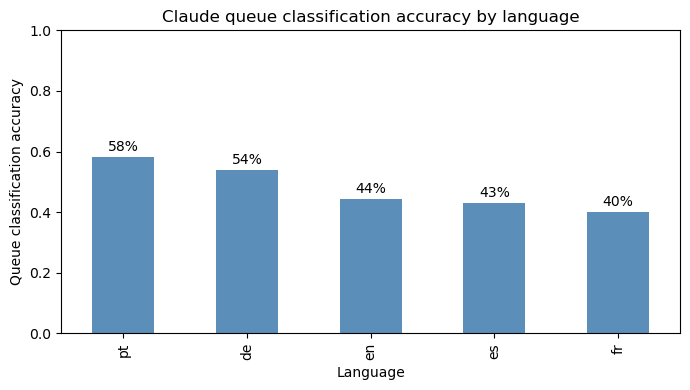

In [43]:
import matplotlib.pyplot as plt

lang_acc = results.groupby("language")["queue_correct"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
lang_acc.plot(kind="bar", ax=ax, color="#5B8FB9")
ax.set_ylabel("Queue classification accuracy")
ax.set_xlabel("Language")
ax.set_title("Claude queue classification accuracy by language")
ax.set_ylim(0, 1)
for i, v in enumerate(lang_acc.values):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center")
plt.tight_layout()
plt.show()


In [44]:
summary = pd.DataFrame({
    "metric": ["overall_queue_accuracy", "overall_priority_accuracy", "n_tickets"],
    "value": [queue_acc, priority_acc, n],
})
summary.to_csv("metrics_summary.csv", index=False)
summary


,metric,value
0,overall_queue_accuracy,0.472
1,overall_priority_accuracy,0.588
2,n_tickets,250.000


## 5. Spot-check reply drafts

Compare a few Claude-generated reply drafts against the original human agent replies.


In [45]:
for i, row in results.sample(3, random_state=1).iterrows():
    print("=" * 80)
    print(f"[{row['language']}] {row['subject']}")
    print("-- Human reply --")
    print(row["true_answer"][:300])
    print("-- Claude draft --")
    print(row["pred_reply_draft"])


[fr] Demande d'informations sur l'imprimante Epson EcoTank ET-4760
-- Human reply --
Bonjour,

Merci de nous avoir contactés concernant votre demande d'informations sur l'imprimante Epson EcoTank ET-4760. L'ET-4760 est équipée de fonctionnalités telles que l'impression sans fil et les capacités de numérisation, permettant un accès pratique à distance et une utilisation multifonction
-- Claude draft --
Bonjour, merci de nous avoir contactés au sujet de l'imprimante Epson EcoTank ET-4760 ! Cette imprimante propose effectivement des fonctionnalités très appréciées telles que l'impression sans fil, la numérisation, la copie et la télécopie, ainsi qu'un système de réservoirs d'encre rechargeables offrant un coût d'impression réduit sur le long terme. Nous allons vérifier pour vous la disponibilité en stock, les délais de livraison estimés, ainsi que les éventuelles promotions en cours, et nous vous fournirons ces informations dans les plus brefs délais. N'hésitez pas à nous poser toute ques